In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import anafibre as fib
from astropy import units as u
from astropy.constants import eps0
from scipy.special import spherical_jn, spherical_yn
from scipy.constants import epsilon_0

In [2]:
fibre = fib.StepIndexFibre(
    core_radius = 250*u.nm,     # core radius
    n_core = 2.02,              # refractive index of core      
    n_clad = 1.33,              # refractive index of cladding
) 

In [3]:
lam = 637*u.nm    # wavelength
CPmode = fibre.HE(ell=1, n=1, wl=lam, a_plus=0, a_minus=1)
XPmode = fibre.HE(ell=1, n=1, wl=lam, a_plus=1/np.sqrt(2), a_minus=1/np.sqrt(2))
YPmode = fibre.HE(ell=1, n=1, wl=lam, a_plus=1j/np.sqrt(2), a_minus=-1j/np.sqrt(2))
fib.display_modes(CPmode, XPmode, YPmode)

Mode,λ [nm],V,ne,s1,s2,s3
HE11,6.37e-07,3.75,1.8460,0.00,0.00,-1.00
HE11,6.37e-07,3.75,1.8460,1.00,0.00,0.00
HE11,6.37e-07,3.75,1.8460,-1.00,0.00,0.00


In [4]:
def _psi(n, z):
    # Riccati–Bessel psi_n(z) = z j_n(z)
    return z * spherical_jn(n, z)

def _psi_prime(n, z):
    # derivative d/dz [z j_n(z)] = j_n(z) + z j_n'(z)
    return spherical_jn(n, z) + z * spherical_jn(n, z, derivative=True)

def _xi(n, z):
    # Riccati–Hankel xi_n(z) = z h_n^{(1)}(z) = z (j_n + i y_n)
    return z * (spherical_jn(n, z) + 1j * spherical_yn(n, z))

def _xi_prime(n, z):
    # derivative d/dz [z h_n^{(1)}(z)] = h_n^{(1)}(z) + z (h_n^{(1)})'(z)
    jn  = spherical_jn(n, z)
    yn  = spherical_yn(n, z)
    jnp = spherical_jn(n, z, derivative=True)
    ynp = spherical_yn(n, z, derivative=True)
    hn  = jn + 1j * yn
    hnp = jnp + 1j * ynp
    return hn + z * hnp

def mie_a1(R_m, lam_vac_m, eps_p_rel, n_m):
    """
    Electric dipole Mie coefficient a1 for a sphere in a non-magnetic host medium.

    R_m: sphere radius (m)
    lam_vac_m: vacuum wavelength (m)
    eps_p_rel: particle relative permittivity (complex), e.g. gold at lambda
    n_m: host refractive index (real), e.g. fibre.n_clad

    Returns: a1 (complex)
    """
    # host wavenumber
    k = 2*np.pi*n_m/lam_vac_m
    x = k * R_m

    # relative refractive index m = n_p / n_m
    n_p = np.sqrt(eps_p_rel)      # principal branch; fine for metals if eps is consistent
    mrel = n_p / n_m
    mx = mrel * x

    n = 1
    psi_x   = _psi(n, x)
    psi_mx  = _psi(n, mx)
    psi_x_p  = _psi_prime(n, x)
    psi_mx_p = _psi_prime(n, mx)

    xi_x    = _xi(n, x)
    xi_x_p  = _xi_prime(n, x)

    # Standard Mie coefficient for non-magnetic sphere (μ=1):
    # a_n = [ m ψ_n(mx) ψ_n'(x) - ψ_n(x) ψ_n'(mx) ] / [ m ψ_n(mx) ξ_n'(x) - ξ_n(x) ψ_n'(mx) ]
    num = mrel * psi_mx * psi_x_p - psi_x * psi_mx_p
    den = mrel * psi_mx * xi_x_p  - xi_x  * psi_mx_p
    return num / den

def alpha_mie_dipole(R_m, lam_vac_m, eps_p_rel, n_m):
    """
    Electric dipole polarizability from Mie theory:
      alpha = (6π i / k^3) a1

    Returns alpha in SI (C m^2 / V).
    """
    k = 2*np.pi*n_m/lam_vac_m
    a1 = mie_a1(R_m, lam_vac_m, eps_p_rel, n_m)
    alpha = (6*np.pi*1j / k**3) * a1

    # This alpha corresponds to the dipole moment convention used with E in V/m:
    # p = epsilon_0 * epsilon_m * alpha_eff?  <-- different communities pack factors differently.
    #
    # Your existing force code expects alpha in SI such that p = alpha * E.
    # The (6π i / k^3) a1 form is the "scattering-polarizability" commonly used in nano-optics.
    return alpha
def alpha_mie_dipole_SI(R_m, lam_vac_m, eps_p_rel, n_m):
    """
    SI polarizability alpha_SI (C m^2 / V) for p = alpha_SI * E,
    derived from electric dipole Mie coefficient a1.

    Uses: alpha_Mie = (6π i / k^3) a1   [units ~ m^3]
          alpha_SI  = ε0 εm * alpha_Mie
    """
    eps_m_rel = n_m**2
    k = 2*np.pi*n_m/lam_vac_m

    a1 = mie_a1(R_m, lam_vac_m, eps_p_rel, n_m)     # your existing a1
    alpha_m3 = (6*np.pi*1j / k**3) * a1             # ~ m^3 convention
    alpha_SI = epsilon_0 * eps_m_rel * alpha_m3     # C m^2 / V

    return alpha_SI

In [5]:
eps_par = -12.7872 +1j*1.5663   # relative permittivity of gold at 637 nm

def alpha_e(R, lam_vac=lam, eps_p=eps_par, fibre=fibre):
    """
    Clausius–Mossotti + radiation reaction correction in a dielectric medium.
    lam_vac: vacuum wavelength (m)
    """
    
    n_m = fibre.n_clad(lam_vac)
    eps_m = n_m**2
    k_m = 2*np.pi*n_m/lam_vac

    alpha0 = 4*np.pi*eps0*eps_m * R**3 * (eps_p - eps_m) / (eps_p + 2*eps_m)
    alpha  = alpha0 / (1.0 - 1j * (k_m**3) * alpha0 / (6*np.pi*eps0*eps_m))
    return alpha

def alpha_e_mie(R):
    R_m   = R.to_value(u.m)
    lam_m = lam.to_value(u.m)
    n_m   = fibre.n_clad(lam)
    return alpha_mie_dipole_SI(R_m, lam_m, eps_par, n_m) * (u.C*u.m**2/u.V)

In [6]:
# def gradE(Efun, x0, y0, z0=0.0, hx=1e-9, hy=None, hz=None):
#     """
#     Full gradient (Jacobian) of the complex vector field E at a point.
    
#     Parameters
#     ----------
#     Efun : callable
#         Efun(x,y,z) -> array-like shape (3,) complex, i.e. [Ex,Ey,Ez].
#     x0,y0,z0 : float
#         Evaluation point (meters).
#     hx,hy,hz : float
#         Step sizes in x,y,z (meters). hy/hz default to hx.

#     Returns
#     -------
#     J : np.ndarray
#         Complex array shape (3,3), where:
#           J[:,0] = dE/dx
#           J[:,1] = dE/dy
#           J[:,2] = dE/dz
#         i.e. J[i,j] = ∂_j E_i.
#     """
#     if hy is None: hy = hx
#     if hz is None: hz = hx

#     # Evaluate E at offset points
#     E_xp = Efun(x0+hx, y0,    z0)
#     E_xm = Efun(x0-hx, y0,    z0)
#     E_yp = Efun(x0,    y0+hy, z0)
#     E_ym = Efun(x0,    y0-hy, z0)
#     E_zp = Efun(x0,    y0,    z0+hz)
#     E_zm = Efun(x0,    y0,    z0-hz)

#     dEdx = (E_xp - E_xm) / (2*hx)
#     dEdy = (E_yp - E_ym) / (2*hy)
#     dEdz = (E_zp - E_zm) / (2*hz)

#     J = np.column_stack([dEdx, dEdy, dEdz])  # (3,3)
#     return J
def Ei_djEi(mode, x0, y0, z0=0.0, hx=1e-9):
    """
    Returns g (3,) complex with components g_j = Σ_i E_i^* ∂_j E_i
    """
    E0 = mode.E(x0, y0, z0)
    # J  = gradE(mode.E, x0, y0, z0, hx=hx)                  # (3,3), J[i,j]=∂_j E_i
    J = mode.gradE(x=x0, y=y0, z=z0)


    g = np.conj(E0) @ J   # (3,) where g[j] = Σ_i conj(E_i) * J[i,j]
    return g
def force_dipole(Efun, R):
    """
    Force vector:
      F_j = 0.5 * Re[ alpha^* * Σ_i E_i^* ∂_j E_i ]

    Returns numpy array (3,) in SI Newtons if your E is in V/m/√W and alpha in SI.
    """
    F=np.real((np.conjugate(alpha_e_mie(R))*Ei_djEi(Efun, CPmode.fibre.core_radius+(2*u.nm+R).to_value(u.m), 0)*(u.V/u.m)**2/u.m).si)
    return F

In [7]:
force_dipole(CPmode, 100*u.nm)/u.W

<Quantity [-1.17086989e-11, -3.98507606e-12,  8.23457993e-11] N / W>

In [8]:
force_dipole(XPmode, 100*u.nm)/u.W

<Quantity [-1.79358742e-11,  0.00000000e+00,  1.25242155e-10] N / W>

In [9]:
force_dipole(YPmode, 100*u.nm)/u.W

<Quantity [-5.48152364e-12,  0.00000000e+00,  3.94494441e-11] N / W>

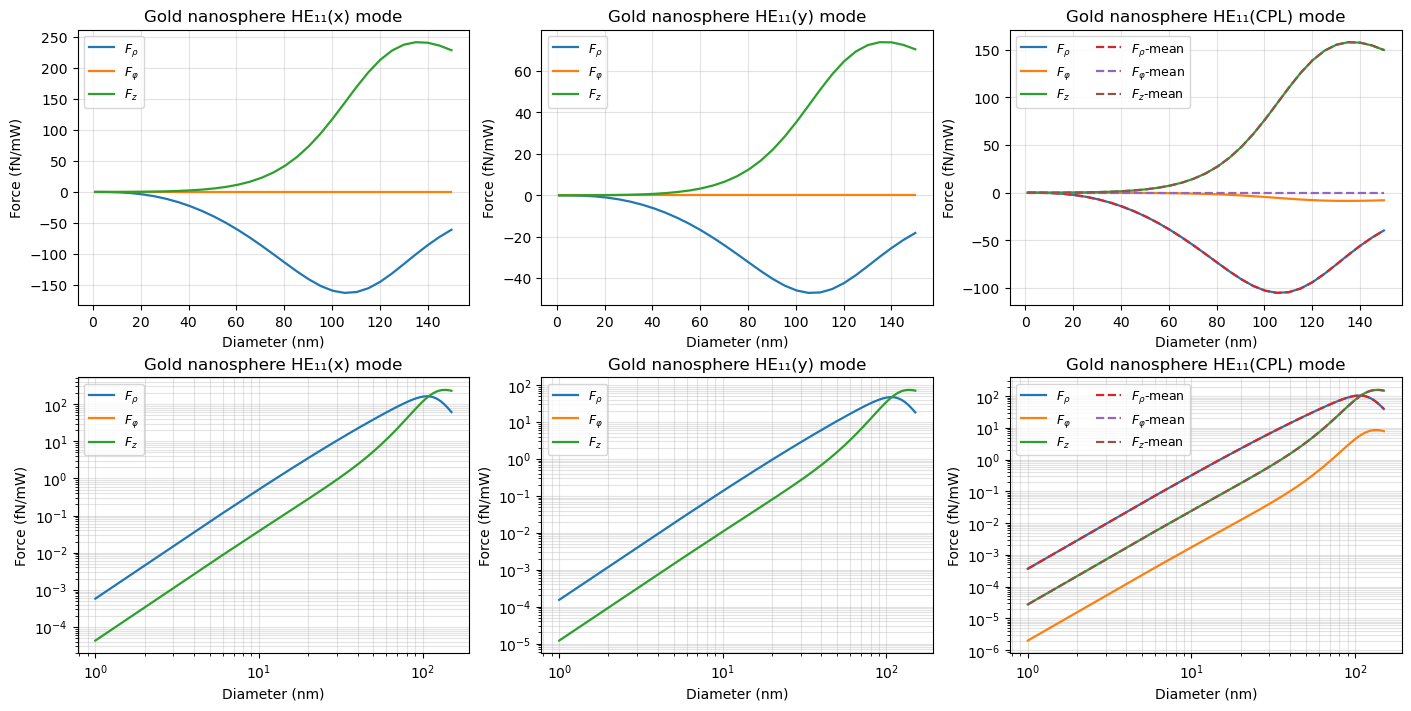

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Diameter array
# -------------------------------------------------
Ds = np.linspace(1, 150, 31)* u.nm

# -------------------------------------------------
# 2. Geometry
# -------------------------------------------------
gap = 2*u.nm
a_m = CPmode.fibre.core_radius*u.m

# -------------------------------------------------
# 3. Allocate force arrays
# -------------------------------------------------
F_XP = np.zeros((len(Ds), 3))
F_YP = np.zeros((len(Ds), 3))
F_CP = np.zeros((len(Ds), 3))

# -------------------------------------------------
# 4. Diameter sweep (USES YOUR EXISTING FUNCTIONS)
# -------------------------------------------------
for i, D in enumerate(Ds):
    R = 0.5 * D

    F_XP[i, :] = (force_dipole(XPmode, R)/u.W).to(u.fN / u.mW)
    F_YP[i, :] = (force_dipole(YPmode, R)/u.W).to(u.fN / u.mW)
    F_CP[i, :] = (force_dipole(CPmode, R)/u.W).to(u.fN / u.mW)

# -------------------------------------------------
# 6. Plot (same as your reference)
# -------------------------------------------------
modes  = [F_XP, F_YP, F_CP]
titles = ["Gold nanosphere HE₁₁(x) mode",
          "Gold nanosphere HE₁₁(y) mode",
          "Gold nanosphere HE₁₁(CPL) mode"]

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]
labels = [r"$F_\rho$", r"$F_\varphi$", r"$F_z$"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

# linear

for col in range(3):
    ax = axes[0, col]
    for k in range(3):
        ax.plot(Ds, modes[col][:, k], lw=1.6,
                color=colors[k], label=f"{labels[k]}")
    if col == 2:
        for k in range(3):
            axes[0, 2].plot(Ds, (modes[0][:, k]+modes[1][:, k])/2, lw=1.6, linestyle='--',
                    color=colors[k+3], label=f"{labels[k]}-mean")
    ax.set_title(titles[col])
    ax.set_xlabel("Diameter (nm)")
    ax.set_ylabel("Force (fN/mW)")
    ax.grid(True, alpha=0.35)
    if col == 2:
        ax.legend(fontsize=9, loc='upper left', ncol=2)
    else:
        ax.legend(fontsize=9)   

    # ax.set_xlim(0, 150)

# ax.legend(fontsize=9)
# log
for col in range(3):
    ax = axes[1, col]
    for k in range(3):
        ax.loglog(Ds, np.abs(modes[col][:, k]), lw=1.6,
                  color=colors[k], label=f"{labels[k]}")
    if col == 2:
        for k in range(3):
            axes[1, 2].loglog(Ds, np.abs((modes[0][:, k]+modes[1][:, k])/2), lw=1.6, linestyle='--',
                    color=colors[k+3], label=f"{labels[k]}-mean")
    ax.set_title(titles[col])
    ax.set_xlabel("Diameter (nm)")
    ax.set_ylabel("Force (fN/mW)")
    
    ax.grid(True, which="both", alpha=0.35)
    if col == 2:
        ax.legend(fontsize=9, loc='upper left', ncol=2)
    else:
        ax.legend(fontsize=9)

plt.show()


In [11]:
# from anafibre.plotting import  animate_fields_xy
# from IPython.display import display, HTML, Latex
# from matplotlib.animation import PillowWriter
# anim = animate_fields_xy(modes=CPmode, show=("E",),figsize=(4,4))
# anim._fig.axes[0].set_title("HE₁₁(CPL) mode")
# anim.save(
#     "EL_field.gif",
#     writer=PillowWriter(fps=20)
# )
# display(HTML(anim.to_jshtml()))

In [12]:
# from anafibre.plotting import  animate_fields_xy
# from IPython.display import display, HTML, Latex
# from matplotlib.animation import PillowWriter
# anim = animate_fields_xy(modes=XPmode, show=("E",),figsize=(4,4))
# anim._fig.axes[0].set_title("HE₁₁(x) mode")
# display(HTML(anim.to_jshtml()))
# anim.save(
#     "Ex_field.gif",
#     writer=PillowWriter(fps=20)
# )

In [13]:
# from anafibre.plotting import  animate_fields_xy
# from IPython.display import display, HTML, Latex
# from matplotlib.animation import PillowWriter
# anim = animate_fields_xy(modes=YPmode, show=("E",),figsize=(4,4))
# anim._fig.axes[0].set_title("HE₁₁(y) mode")
# display(HTML(anim.to_jshtml()))
# anim.save(
#     "Ey_field.gif",
#     writer=PillowWriter(fps=20)
# )